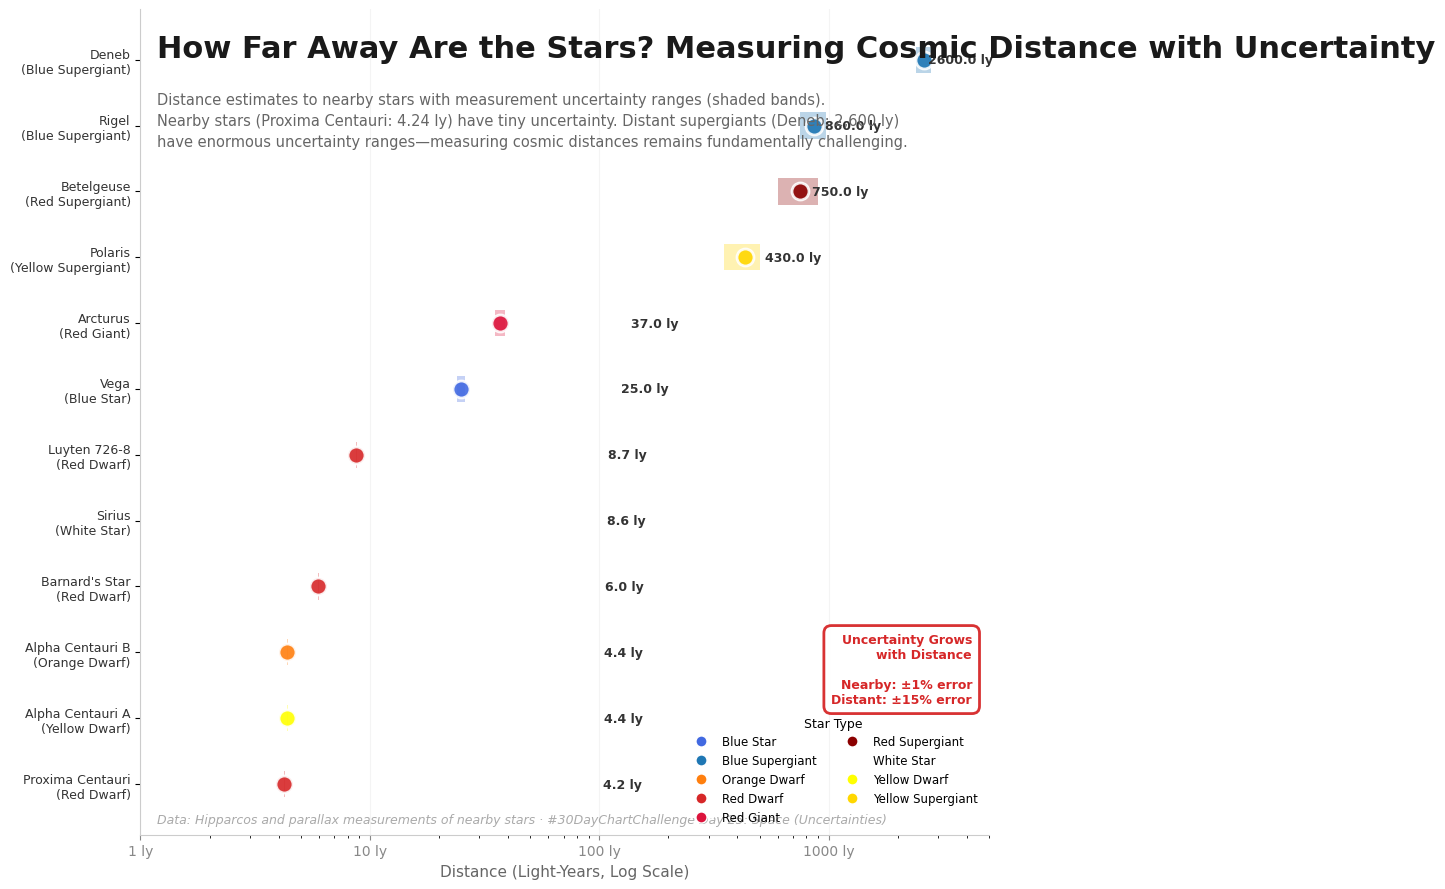

In [1]:
"""
#30DayChartChallenge — Day 25: Space (Uncertainties)
"How Far Away Are the Stars? Measuring Cosmic Distance with Uncertainty" — spatial data with confidence intervals
in the style of FlowingData: minimal chrome, direct labels, clean typography.

Data: Distance estimates to nearby stars with measurement uncertainty ranges
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 1. SAMPLE DATA — Distance to nearby stars with uncertainty ranges (light-years)
# ---------------------------------------------------------------------------
data = {
    "Star": [
        "Proxima Centauri",
        "Alpha Centauri A",
        "Alpha Centauri B",
        "Barnard's Star",
        "Luyten 726-8",
        "Sirius",
        "Betelgeuse",
        "Rigel",
        "Polaris",
        "Deneb",
        "Vega",
        "Arcturus"
    ],
    "Distance_ly": [4.24, 4.37, 4.37, 5.96, 8.73, 8.6, 750, 860, 430, 2600, 25, 37],
    "Uncertainty_Low": [4.22, 4.35, 4.35, 5.94, 8.70, 8.55, 600, 750, 350, 2400, 24, 35],
    "Uncertainty_High": [4.26, 4.39, 4.39, 5.98, 8.76, 8.65, 900, 970, 500, 2800, 26, 39],
    "Type": [
        "Red Dwarf", "Yellow Dwarf", "Orange Dwarf", "Red Dwarf", "Red Dwarf",
        "White Star", "Red Supergiant", "Blue Supergiant", "Yellow Supergiant",
        "Blue Supergiant", "Blue Star", "Red Giant"
    ]
}

df = pd.DataFrame(data)
df = df.sort_values("Distance_ly")

# ---------------------------------------------------------------------------
# 2. PLOT
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 9), facecolor="#FFFFFF")
ax.set_facecolor("#FFFFFF")

# Color by star type
type_colors = {
    "Red Dwarf": "#d62728",
    "Yellow Dwarf": "#ffff00",
    "Orange Dwarf": "#ff7f0e",
    "White Star": "#ffffff",
    "Red Supergiant": "#8b0000",
    "Blue Supergiant": "#1f77b4",
    "Yellow Supergiant": "#ffd700",
    "Blue Star": "#4169e1",
    "Red Giant": "#dc143c"
}

# Plot uncertainty ranges as horizontal error bars
for i, (idx, row) in enumerate(df.iterrows()):
    # Error range bar
    ax.barh(i, row["Uncertainty_High"] - row["Uncertainty_Low"],
            left=row["Uncertainty_Low"], height=0.4, 
            color=type_colors[row["Type"]], alpha=0.3, edgecolor="none", zorder=1)
    
    # Main distance point
    ax.scatter(row["Distance_ly"], i, s=150, color=type_colors[row["Type"]], 
               edgecolor="white", linewidth=2, zorder=3, alpha=0.9)
    
    # Distance label
    ax.text(row["Distance_ly"] + 100, i, f"{row['Distance_ly']:.1f} ly",
            fontsize=9, fontweight="600", color="#333333", va="center")

# Y-axis labels with star types
labels = [f"{row['Star']}\n({row['Type']})" for _, row in df.iterrows()]
ax.set_yticks(range(len(df)))
ax.set_yticklabels(labels, fontsize=9, fontweight="500", color="#333333")

# Minimal styling
ax.set_xscale("log")  # Log scale for readability (huge range)
ax.set_xlim(1, 5000)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#cccccc")
ax.grid(True, color="#eeeeee", linewidth=0.8, alpha=0.6, axis="x", zorder=0)
ax.set_axisbelow(True)

ax.set_xlabel("Distance (Light-Years, Log Scale)", fontsize=11, color="#666666", fontweight="500")
ax.set_xticks([1, 10, 100, 1000])
ax.set_xticklabels(["1 ly", "10 ly", "100 ly", "1000 ly"], fontsize=10, color="#888888")
ax.tick_params(colors="#888888", labelsize=10, axis="x")

# Title & subtitle
ax.text(0.02, 0.97, "How Far Away Are the Stars? Measuring Cosmic Distance with Uncertainty",
        fontsize=22, fontweight="bold", color="#1a1a1a", transform=ax.transAxes, va="top")

ax.text(0.02, 0.90,
        "Distance estimates to nearby stars with measurement uncertainty ranges (shaded bands).\n"
        "Nearby stars (Proxima Centauri: 4.24 ly) have tiny uncertainty. Distant supergiants (Deneb: 2,600 ly)\n"
        "have enormous uncertainty ranges—measuring cosmic distances remains fundamentally challenging.",
        fontsize=10.5, color="#666666", transform=ax.transAxes, va="top", linespacing=1.5)

# Uncertainty insight
ax.text(0.98, 0.20, "Uncertainty Grows\nwith Distance\n\nNearby: ±1% error\nDistant: ±15% error",
        fontsize=9, color="#d62728", fontweight="bold", transform=ax.transAxes, 
        ha="right", va="center",
        bbox=dict(boxstyle="round,pad=0.6", facecolor="#fff", edgecolor="#d62728", linewidth=2, alpha=0.95))

# Legend for star types
legend_elements = [plt.Line2D([0], [0], marker="o", color="w", 
                              markerfacecolor=type_colors[stype], markersize=8,
                              label=stype, markeredgecolor="white", markeredgewidth=1)
                   for stype in sorted(set(df["Type"]))]
ax.legend(handles=legend_elements, loc="lower right", fontsize=8.5, frameon=False, 
          title="Star Type", title_fontsize=9, ncol=2)

# Source
ax.text(0.02, 0.01,
        "Data: Hipparcos and parallax measurements of nearby stars · #30DayChartChallenge Day 25: Space (Uncertainties)",
        fontsize=9, color="#aaaaaa", style="italic", transform=ax.transAxes, va="bottom")

plt.tight_layout()
plt.savefig("day25_space.png", dpi=200, facecolor="#FFFFFF", bbox_inches="tight")
plt.show()